# Tebas Fairplay Report (Fantasy S2)

In [1]:
import datetime
import numpy as np
import pandas as pd

trading_df = pd.read_csv('../data/trading.csv')
trading_df['date'] = pd.to_datetime(trading_df['date']).dt.date
trading_df.head(10)

,date,type,team1,team2,player,amount
0,2026-03-21,sold,Ramonaco FC,LALIGA,Marcos Alonso,84696518
1,2026-03-21,purchased,Millou912,La rataneta,Jon Martin,1600000
2,2026-03-20,purchased,LamineTheTuareg,cristian.ayala12,Akor,3600000
3,2026-03-20,purchased,LamineTheTuareg,cristian.ayala12,Torro,1110000
4,2026-03-20,purchased,LamineTheTuareg,La rataneta,Lemar,1800000
5,2026-03-20,purchased,-papi—,LALIGA,Fer Lépez,7000000
6,2026-03-20,purchased,cristian.ayala12,LALIGA,De Frutos,40910688
7,2026-03-19,sold,PlatanosVerdes,LALIGA,Youssef,704788
8,2026-03-19,purchased,tete alejo,LALIGA,Bardghji,800000
9,2026-03-19,purchased,PlatanosVerdes,LALIGA,A. Pedraza,1012584


## Transactions

### All transactions plot

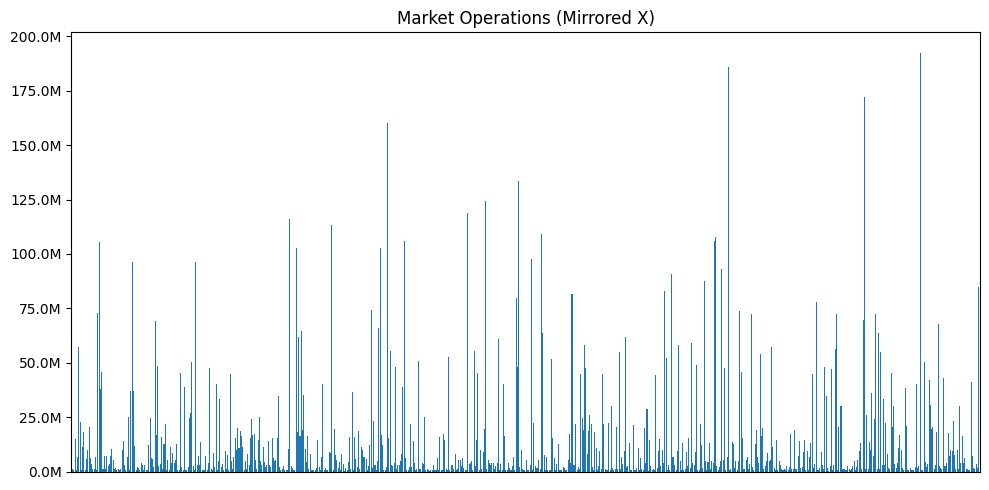

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10,5))

ax.bar(trading_df.index, trading_df['amount'])

# Invertir eix X
off = 1
ax.set_xlim(-off, len(trading_df) - off)
ax.invert_xaxis()

# Format milions
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

plt.title('Market Operations (Mirrored X)')
plt.xticks([])

plt.tight_layout()
plt.show()

### Top transactions

In [3]:
trading_df.sort_values('amount', ascending=False).head(15)

,date,type,team1,team2,player,amount
46,2026-03-17,sold,Ramonaco FC,LALIGA,Vini Jr.,192220472
197,2026-03-02,purchased,La rataneta,LALIGA,Lamine Yamal,186047732
90,2026-03-11,purchased,Ramonaco FC,LALIGA,Vini Jr.,171892491
465,2026-02-03,purchased,LILTEAM,LALIGA,Mbappé,160000000
362,2026-02-13,sold,cristian.ayala12,LALIGA,Valverde,133631252
388,2026-02-11,sold,Millou912,LALIGA,Vini Jr.,124154664
402,2026-02-10,purchased,Millou912,LALIGA,Vini Jr.,118836312
542,2026-01-27,sold,LILTEAM,LALIGA,Antony,116209495
509,2026-01-30,purchased,cristian.ayala12,Ramonaco FC,Valverde,113368973
344,2026-02-16,sold,Ramonaco FC,LALIGA,Julian Alvarez,109214101


### Daily stats

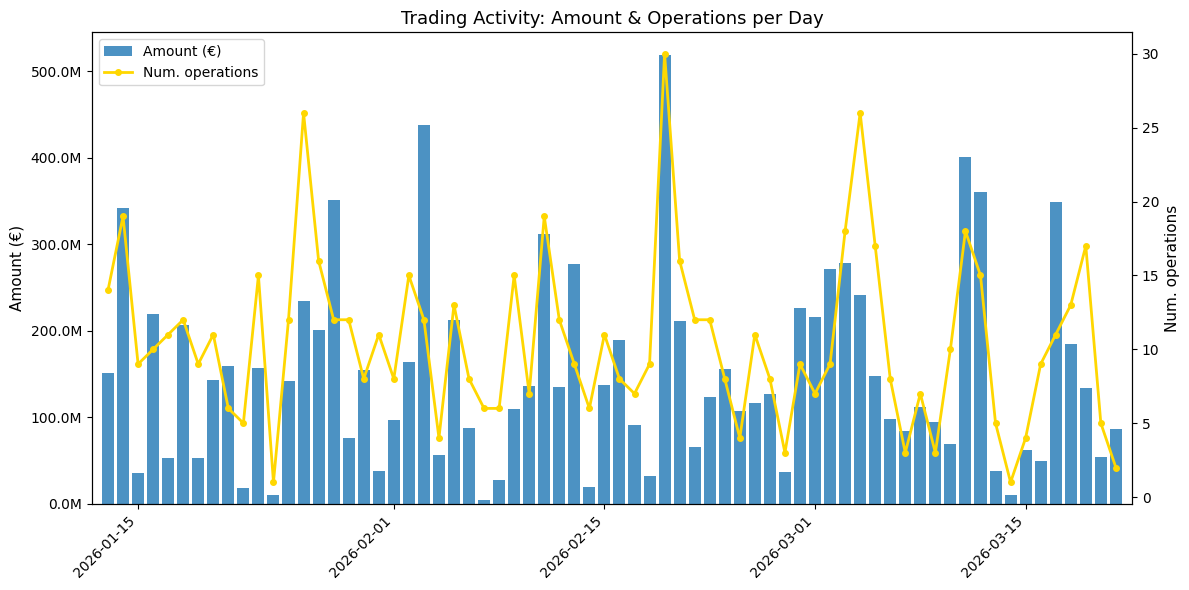

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import datetime

# --- Aggregation ---
date_groups = trading_df.groupby('date')

daily_amount = date_groups['amount'].sum()
daily_counts = trading_df['date'].value_counts()

# Full date range
full_range = pd.date_range(trading_df['date'].min(), trading_df['date'].max())

daily_amount = daily_amount.reindex(full_range, fill_value=0)
daily_counts = daily_counts.reindex(full_range, fill_value=0)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(12,6))

# Bars (amount)
bars = ax1.bar(
    daily_amount.index,
    daily_amount,
    width=0.8,
    alpha=0.8,
    label='Amount (€)'
)

ax1.set_ylabel('Amount (€)', fontsize=11)

# Format Y axis in millions
ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

# Line (counts)
ax2 = ax1.twinx()
ax2.plot(
    daily_counts.index,
    daily_counts,
    marker='o',
    color='gold',
    linewidth=2,
    markersize=4,
    label='Num. operations'
)

ax2.set_ylabel('Num. operations', fontsize=11)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper left'
)

# --- X axis formatting (KEY PART) ---
ax1.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=8))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')

# --- Baseline ---
ax1.axhline(0, linewidth=0.6, color='black', alpha=0.6)

# --- Margins ---
ax1.margins(x=0.01)

# --- Title ---
plt.title('Trading Activity: Amount & Operations per Day', fontsize=13)

# --- Layout ---
plt.tight_layout()

plt.show()

#### Top days with more amount

In [5]:
dd = daily_amount.sort_values(ascending=False)
display(dd)
date_groups.get_group(dd.index[0].date())

2026-02-19    518762461
2026-02-03    437345511
2026-03-11    400498700
2026-03-12    360767106
2026-01-28    350817669
                ...    
2026-02-14     19545359
2026-01-22     18393833
2026-03-14     10000000
2026-01-24      9500000
2026-02-07      4014859
Name: amount, Length: 68, dtype: int64

,date,type,team1,team2,player,amount
291,2026-02-19,sold,LILTEAM,LALIGA,Cancelo,22203918
292,2026-02-19,sold,-papi—,LALIGA,A. Abqar,639349
293,2026-02-19,sold,-papi—,LALIGA,Chimy Avila,562359
294,2026-02-19,purchased,-papi—,JMjugon,M. Roman,1100069
295,2026-02-19,purchased,tete alejo,-papi—,Alvaro Garcia,22000000
296,2026-02-19,purchased,tete alejo,Millou912,Arambarri,44862050
297,2026-02-19,purchased,cristian.ayala12,tete alejo,Pol Lozano,1000000
298,2026-02-19,purchased,JMjugon,LALIGA,Raul Moro,9300069
299,2026-02-19,purchased,La rataneta,LALIGA,Obed Vargas,2694485
300,2026-02-19,purchased,Millou912,LALIGA,Dimitrievski,617763


#### Top days with more operations

In [6]:
dd = daily_counts.sort_values(ascending=False)
display(dd)
date_groups.get_group(dd.index[0].date())

2026-02-19    30
2026-01-26    26
2026-03-04    26
2026-01-14    19
2026-02-11    19
              ..
2026-02-27     3
2026-03-09     3
2026-03-21     2
2026-01-24     1
2026-03-14     1
Name: count, Length: 68, dtype: int64

,date,type,team1,team2,player,amount
291,2026-02-19,sold,LILTEAM,LALIGA,Cancelo,22203918
292,2026-02-19,sold,-papi—,LALIGA,A. Abqar,639349
293,2026-02-19,sold,-papi—,LALIGA,Chimy Avila,562359
294,2026-02-19,purchased,-papi—,JMjugon,M. Roman,1100069
295,2026-02-19,purchased,tete alejo,-papi—,Alvaro Garcia,22000000
296,2026-02-19,purchased,tete alejo,Millou912,Arambarri,44862050
297,2026-02-19,purchased,cristian.ayala12,tete alejo,Pol Lozano,1000000
298,2026-02-19,purchased,JMjugon,LALIGA,Raul Moro,9300069
299,2026-02-19,purchased,La rataneta,LALIGA,Obed Vargas,2694485
300,2026-02-19,purchased,Millou912,LALIGA,Dimitrievski,617763


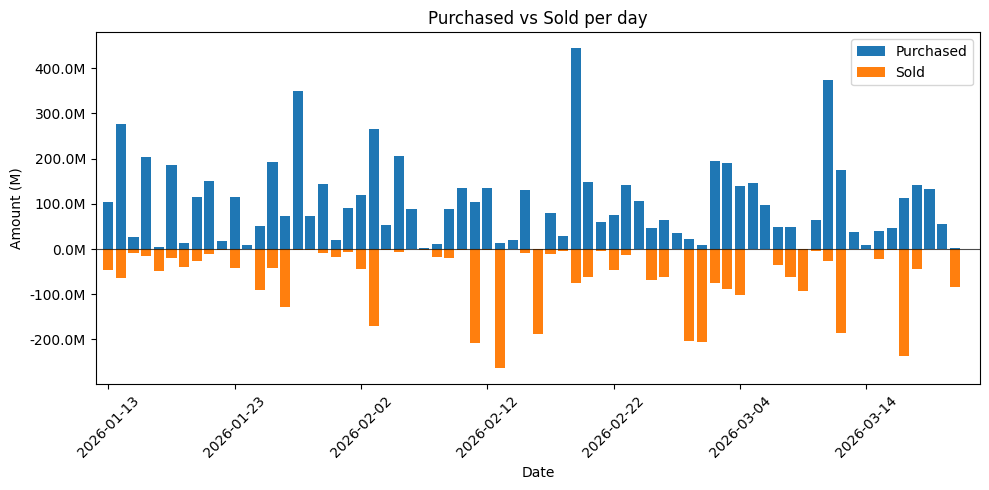

In [7]:
full_range = pd.date_range(trading_df['date'].min(), trading_df['date'].max())

daily = trading_df.groupby(['date', 'type'])['amount'].sum().unstack(fill_value=0)
daily = daily.reindex(full_range, fill_value=0)
daily = daily.reindex(columns=['purchased', 'sold'], fill_value=0)

plt.figure(figsize=(10,5))

# Purchased (positive)
x = np.arange(len(daily))
plt.bar(x, daily['purchased'], label='Purchased')
plt.bar(x, -daily['sold'], label='Sold')

plt.xticks(x, daily.index.strftime('%Y-%m-%d'), rotation=45)

plt.title('Purchased vs Sold per day')
plt.xlim(-1, len(x)+1)
plt.xlabel('Date')
plt.ylabel('Amount (M)')

step= 10
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(x[::step], daily.index.strftime('%Y-%m-%d')[::step], rotation=45)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
daily['diff'] = daily['sold'] - daily['purchased']
daily

type,purchased,sold,diff
2026-01-13,104276294,46271593,-58004701
2026-01-14,277528645,63748033,-213780612
2026-01-15,26750001,8431704,-18318297
2026-01-16,203500840,15240395,-188260445
2026-01-17,4221331,48762351,44541020
...,...,...,...
2026-03-17,112050711,236893316,124842605
2026-03-18,141010157,44101204,-96908953
2026-03-19,132581084,704788,-131876296
2026-03-20,54420688,0,-54420688


## Teams

## Fairplay

In [9]:
print(trading_df['player'].value_counts())

player
Alvaro Garcia    8
Ounahi           5
Gorrotxa         5
Witsel           5
Cardona          5
                ..
Isco             1
Puado            1
D. Martinez      1
Giuliano         1
David Soria      1
Name: count, Length: 344, dtype: int64


In [10]:
trading_df['fp'] = np.nan
for player, group_df in trading_df.groupby('player'):
    fp = group_df['date'].iloc[::-1].diff()
    if len(fp) > 1:
        for idx, value in fp.items():
            row = trading_df.loc[idx]
            trading_df.at[idx, 'fp'] = float(value.days)

trading_df

,date,type,team1,team2,player,amount,fp
0,2026-03-21,sold,Ramonaco FC,LALIGA,Marcos Alonso,84696518,9.0
1,2026-03-21,purchased,Millou912,La rataneta,Jon Martin,1600000,20.0
2,2026-03-20,purchased,LamineTheTuareg,cristian.ayala12,Akor,3600000,14.0
3,2026-03-20,purchased,LamineTheTuareg,cristian.ayala12,Torro,1110000,17.0
4,2026-03-20,purchased,LamineTheTuareg,La rataneta,Lemar,1800000,14.0
...,...,...,...,...,...,...,...
710,2026-01-13,purchased,La rataneta,LALIGA,Vilaplana,584831,NaN
711,2026-01-13,purchased,La Agustineta 96,LALIGA,David Soria,15000000,NaN
712,2026-01-13,purchased,La rataneta,LALIGA,Marc Bernal,710000,NaN
713,2026-01-13,purchased,Ramonaco FC,LALIGA,Kiko F.,1251000,NaN


In [11]:
trading_df[~trading_df['fp'].isnull()]

,date,type,team1,team2,player,amount,fp
0,2026-03-21,sold,Ramonaco FC,LALIGA,Marcos Alonso,84696518,9.0
1,2026-03-21,purchased,Millou912,La rataneta,Jon Martin,1600000,20.0
2,2026-03-20,purchased,LamineTheTuareg,cristian.ayala12,Akor,3600000,14.0
3,2026-03-20,purchased,LamineTheTuareg,cristian.ayala12,Torro,1110000,17.0
4,2026-03-20,purchased,LamineTheTuareg,La rataneta,Lemar,1800000,14.0
...,...,...,...,...,...,...,...
621,2026-01-20,sold,JMjugon,LALIGA,Alvaro Nufiez,24555404,4.0
630,2026-01-20,purchased,JMjugon,LALIGA,Alvaro Garcia,581988,2.0
636,2026-01-19,sold,-papi—,LALIGA,A. Batalla,11375056,1.0
637,2026-01-19,sold,-papi—,LALIGA,Stuani,589292,5.0


In [12]:
mask_purchased = (trading_df['type'] == 'purchased') & (trading_df['team2'] != 'LALIGA')
mask_sold = (trading_df['type'] == 'sold') & (trading_df['team2'] == 'LALIGA')

targets = trading_df[mask_purchased | mask_sold]
display(targets)
targets['team1'].value_counts()

,date,type,team1,team2,player,amount,fp
0,2026-03-21,sold,Ramonaco FC,LALIGA,Marcos Alonso,84696518,9.0
1,2026-03-21,purchased,Millou912,La rataneta,Jon Martin,1600000,20.0
2,2026-03-20,purchased,LamineTheTuareg,cristian.ayala12,Akor,3600000,14.0
3,2026-03-20,purchased,LamineTheTuareg,cristian.ayala12,Torro,1110000,17.0
4,2026-03-20,purchased,LamineTheTuareg,La rataneta,Lemar,1800000,14.0
...,...,...,...,...,...,...,...
702,2026-01-13,sold,LILTEAM,LALIGA,Puado,5542618,NaN
703,2026-01-13,sold,-papi—,LALIGA,D. Martinez,503413,NaN
704,2026-01-13,sold,-papi—,LALIGA,Vargas,18236496,NaN
705,2026-01-13,sold,-papi—,LALIGA,Laporte,11400818,NaN


team1
-papi—              88
Ramonaco FC         57
La rataneta         44
LamineTheTuareg     40
cristian.ayala12    40
Millou912           37
JMjugon             31
La Agustineta 96    30
PlatanosVerdes      28
LILTEAM             28
tete alejo          20
PavelmacuFC         17
Name: count, dtype: int64

In [13]:
qq = targets[targets['fp'] < 6]
qq

,date,type,team1,team2,player,amount,fp
57,2026-03-15,sold,-papi—,LALIGA,Oblak,20946467,5.0
77,2026-03-12,sold,La rataneta,LALIGA,Lejeune,54819768,5.0
82,2026-03-11,sold,Millou912,LALIGA,Raillo,24355235,3.0
114,2026-03-08,sold,-papi—,LALIGA,Bellerin,3009073,5.0
115,2026-03-08,sold,-papi—,LALIGA,Dela,790170,4.0
119,2026-03-08,sold,-papi—,LALIGA,Bryan Gil,1704569,4.0
124,2026-03-06,purchased,tete alejo,cristian.ayala12,De Galarreta,9110000,1.0
132,2026-03-05,purchased,LILTEAM,La rataneta,Kubo,12869000,5.0
162,2026-03-04,sold,tete alejo,LALIGA,Pere Milla,11298289,5.0
194,2026-03-02,sold,-papi—,LALIGA,Griezmann,13665151,5.0


In [28]:
print('Who sells too early, or who buys from someone who sells too early: \n')
display(qq['team1'].value_counts())

Who sells too early, or who buys from someone who sells too early: 



team1
-papi—              11
JMjugon              7
Ramonaco FC          7
La rataneta          3
cristian.ayala12     3
LILTEAM              2
tete alejo           2
Millou912            2
PavelmacuFC          1
Name: count, dtype: int64

In [30]:
trading_df[trading_df['player'] == 'Dela' ]

,date,type,team1,team2,player,amount,fp
115,2026-03-08,sold,-papi—,LALIGA,Dela,790170,4.0
156,2026-03-04,purchased,-papi—,JMjugon,Dela,3000000,15.0
330,2026-02-17,purchased,JMjugon,LALIGA,Dela,785096,NaN


In [33]:
trading_df[trading_df['player'] == 'Dela' ]['amount'][::-1].diff()

330          NaN
156    2214904.0
115   -2209830.0
Name: amount, dtype: float64

In [36]:
trading_df[(trading_df['type'] == 'purchased') & (trading_df['team2'] == 'LALIGA')]['team1'].value_counts()

team1
Ramonaco FC         36
JMjugon             32
cristian.ayala12    28
LamineTheTuareg     26
La rataneta         22
Millou912           19
LILTEAM             19
-papi—              17
PavelmacuFC         17
La Agustineta 96    15
PlatanosVerdes      13
tete alejo          11
Name: count, dtype: int64